<a href="https://colab.research.google.com/github/z4inZM/Python-Mini-Projects/blob/main/Credit_Card_Fraud%20Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pandas numpy scikit-learn imbalanced-learn tensorflow matplotlib seaborn

All libraries imported successfully!
Dataset Shape: (284807, 31)
Training shapes: (227845, 30), Test shapes: (56962, 30)

Applying SMOTE to handle class imbalance...
Resampled Training Target Distribution:
Class
0    227451
1    227451
Name: count, dtype: int64

Training Logistic Regression...
Training Random Forest (This may take 1-2 minutes)...

Building Deep Feedforward Neural Network...
Training Artificial Neural Network...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9316 - loss: 0.1839 - val_accuracy: 0.9305 - val_loss: 0.1518
Epoch 2/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9688 - loss: 0.0855 - val_accuracy: 0.9813 - val_loss: 0.0586
Epoch 3/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9790 - loss: 0.0594 - val_accuracy: 0.9862 - val_loss: 0.0397
Epoch 4/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9846 - loss: 0.0441 - val_accuracy: 0.9932 - val_loss: 0.0199
Epoch 5/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9888 - loss: 0.0327 - val_accuracy: 0.9966 - val_loss: 0.0116
Epoch 6/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9917 - loss: 0.0250 - val_accuracy: 0.9990 - val_loss: 0.0073
Epoch 7/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9932 - loss: 0.0212 - val_accuracy: 0.9999 - val_loss: 0.0043
Epoch 8/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9949 - loss: 0.0168 - val_accu

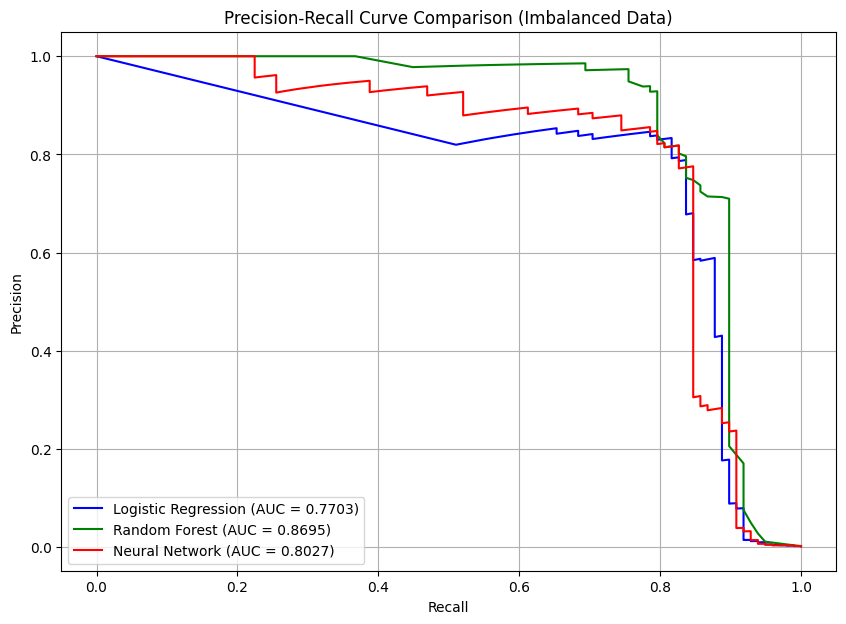


Pipeline complete! Comparison plot saved as precision_recall_comparison.png


In [2]:
# ==========================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

print("All libraries imported successfully!")

# ==========================================
# STEP 2: LOAD AND PREPROCESS DATA
# ==========================================
# Load dataset
df = pd.read_csv('creditcard.csv')
print(f"Dataset Shape: {df.shape}")

# Scale Time and Amount features
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# Drop original Time and Amount columns
df.drop(['Time', 'Amount'], axis=1, inplace=True)

# Split into Features (X) and Target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training shapes: {X_train.shape}, Test shapes: {X_test.shape}")

# ==========================================
# STEP 3: APPLY SMOTE FOR CLASS IMBALANCE
# ==========================================
print("\nApplying SMOTE to handle class imbalance...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"Resampled Training Target Distribution:\n{y_train_res.value_counts()}")

# ==========================================
# STEP 4: TRAIN CLASSICAL ML BASELINES
# ==========================================
# 4.1 Logistic Regression
print("\nTraining Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_res, y_train_res)
y_pred_lr = lr_model.predict(X_test)
y_probs_lr = lr_model.predict_proba(X_test)[:, 1]

# 4.2 Random Forest Classifier
print("Training Random Forest (This may take 1-2 minutes)...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_res, y_train_res)
y_pred_rf = rf_model.predict(X_test)
y_probs_rf = rf_model.predict_proba(X_test)[:, 1]

# ==========================================
# STEP 5: BUILD AND TRAIN DEEP ANN
# ==========================================
print("\nBuilding Deep Feedforward Neural Network...")
ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(16, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Training Artificial Neural Network...")
history = ann_model.fit(
    X_train_res, y_train_res,
    validation_split=0.2,
    epochs=15,
    batch_size=2048,
    callbacks=[early_stop],
    verbose=1
)

y_probs_ann = ann_model.predict(X_test).flatten()
y_pred_ann = (y_probs_ann > 0.5).astype(int)

# ==========================================
# STEP 6: EVALUATION AND METRICS
# ==========================================
def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"\n==================== {name} EVALUATION ====================")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall, precision)
    print(f"Precision-Recall AUC: {pr_auc:.4f}")
    return precision, recall, pr_auc

p_lr, r_lr, auc_lr = evaluate_model("Logistic Regression", y_test, y_pred_lr, y_probs_lr)
p_rf, r_rf, auc_rf = evaluate_model("Random Forest", y_test, y_pred_rf, y_probs_rf)
p_ann, r_ann, auc_ann = evaluate_model("Artificial Neural Network", y_test, y_pred_ann, y_probs_ann)

# ==========================================
# STEP 7: PLOT PRECISION-RECALL CURVES
# ==========================================
plt.figure(figsize=(10, 7))
plt.plot(r_lr, p_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})', color='blue')
plt.plot(r_rf, p_rf, label=f'Random Forest (AUC = {auc_rf:.4f})', color='green')
plt.plot(r_ann, p_ann, label=f'Neural Network (AUC = {auc_ann:.4f})', color='red')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison (Imbalanced Data)')
plt.legend(loc='best')
plt.grid(True)
plt.savefig('precision_recall_comparison.png')
plt.show()
print("\nPipeline complete! Comparison plot saved as precision_recall_comparison.png")